In [5]:
import pandas as pd
import matplotlib.pyplot as plt

archivo = "Datos_CLV_2026_Tec_v2.xlsx"

columnas_salidas = ["fecha", "nombre_articulo", "marca", "salidas"]
columnas_negocios = [
    "nombre_negocio", "estado", "tipo_negocio", "nombre_etapa", "estatus",
    "fecha_creacion", "fecha_cierre", "numero_actividades", "vendedor",
    "nombre_pipeline", "motivo_cierre_perdido", "nombre_zona"
]

df_salidas = pd.read_excel(
    archivo, sheet_name="Salidas_Almacen", usecols=columnas_salidas
)
df_negocios = pd.read_excel(
    archivo, sheet_name="Negocios_CRM", usecols=columnas_negocios
)

for datos, columnas_fecha in [
    (df_salidas, ["fecha"]),
    (df_negocios, ["fecha_creacion", "fecha_cierre"]),
]:
    for columna in columnas_fecha:
        datos[columna] = pd.to_datetime(datos[columna], errors="coerce")

df_salidas["salidas"] = pd.to_numeric(df_salidas["salidas"], errors="coerce")
df_negocios["numero_actividades"] = pd.to_numeric(
    df_negocios["numero_actividades"], errors="coerce"
)

print(f"Salidas_Almacen: {df_salidas.shape[0]:,} filas, {df_salidas.shape[1]} columnas")
print(f"Negocios_CRM: {df_negocios.shape[0]:,} filas, {df_negocios.shape[1]} columnas")

Salidas_Almacen: 27,474 filas, 4 columnas
Negocios_CRM: 5,268 filas, 12 columnas


In [8]:
def analisis_univariado(datos, columnas_numericas, columnas_fecha, nombre_hoja):
    print(f"\nAnálisis univariado: {nombre_hoja}")

    for columna in datos.columns:
        serie = datos[columna]
        faltantes = serie.isna().sum()
        print(f"\n{columna} | faltantes: {faltantes:,} de {len(serie):,}")

        if columna in columnas_fecha:
            fechas = serie.dropna()
            if fechas.empty:
                print("No hay fechas válidas para graficar.")
                continue

            print(f"Rango: {fechas.min().date()} a {fechas.max().date()}")
            frecuencia_mensual = (
                fechas.dt.strftime("%Y-%m").value_counts().sort_index()
            )
            meses = pd.to_datetime(frecuencia_mensual.index, format="%Y-%m")
            fig, ax = plt.subplots(figsize=(10, 4))
            ax.plot(
                meses,
                frecuencia_mensual.values,
                marker="o",
                linewidth=1.5,
            )
            ax.set_title(f"{nombre_hoja}: registros por mes - {columna}")
            ax.set_xlabel("Mes")
            ax.set_ylabel("Número de registros")
            ax.grid(True, alpha=0.3)
            fig.autofmt_xdate()
            fig.tight_layout()
            plt.show()

        elif columna in columnas_numericas:
            valores = serie.dropna()
            print(serie.describe().to_string())
            if valores.empty:
                print("No hay valores numéricos para graficar.")
                continue

            fig, ejes = plt.subplots(1, 2, figsize=(11, 4))
            ejes[0].hist(valores, bins="auto", edgecolor="white")
            ejes[0].set_title(f"{nombre_hoja}: distribución de {columna}")
            ejes[0].set_xlabel(columna)
            ejes[0].set_ylabel("Frecuencia")
            ejes[1].boxplot(valores, vert=False)
            ejes[1].set_title(f"{nombre_hoja}: caja de {columna}")
            ejes[1].set_xlabel(columna)
            fig.tight_layout()
            plt.show()

        else:
            frecuencias = (
                serie.astype("string")
                .fillna("Sin dato")
                .value_counts()
                .head(15)
            )
            print(frecuencias.to_string())
            fig, ax = plt.subplots(figsize=(9, max(4, 0.32 * len(frecuencias))))
            frecuencias.sort_values().plot(kind="barh", ax=ax)
            ax.set_title(f"{nombre_hoja}: categorías más frecuentes - {columna}")
            ax.set_xlabel("Frecuencia")
            ax.set_ylabel(columna)
            fig.tight_layout()
            plt.show()


Análisis univariado: Salidas_Almacen

fecha | faltantes: 0 de 27,474
Rango: 2023-10-10 a 2026-09-03


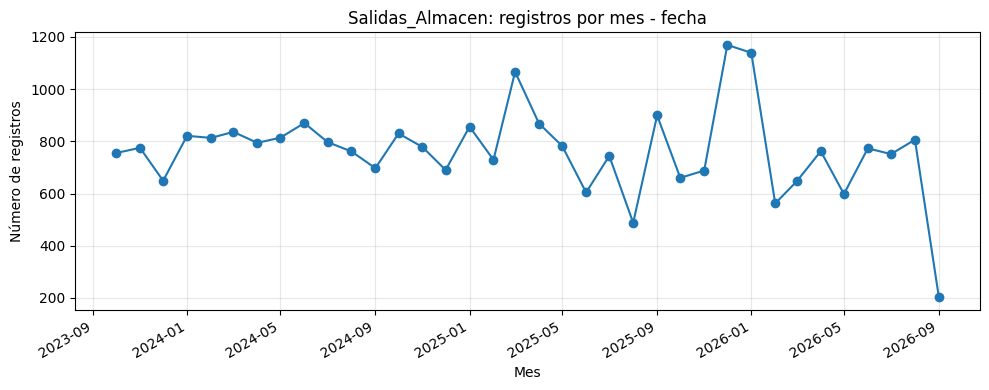


nombre_articulo | faltantes: 0 de 27,474
nombre_articulo
FRESA ROTO RFID 1.0 ZI DM              36
FRESA ROTO RFID 2.5 ZI DM              36
FRESA ROTO RFID 1.0 DIAMOND BLG        36
FRESA ROTO RFID 2.0 DIAMOND BLG        36
FRESA ROTO RFID 2.5 PMMA WAX DM 2.5    36
MFT PU31 2M2                           36
INSYN FC GLAZE PASTE 4G                36
MFT L40 2M1                            36
MIYO GINGIVAL MERLOT PASTE 4G          35
FRESA ROTO RFID 0.6 ZI DM              35
FRESA ROTO RFID 0.4 DIAMOND BLG        35
FRESA ROTO RFID 1.0 PMMA WAX DM 1.0    35
CAMEO MILL BLOCS BOX C14 LT A1         35
CAMEO PRESS INGOT BOX LT B1            35
VMK ENAMEL EN1 12G                     35


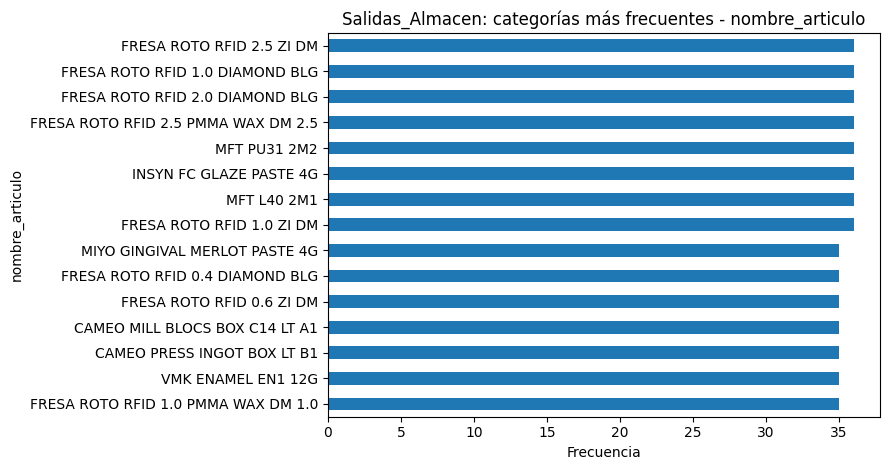


marca | faltantes: 0 de 27,474
marca
Vita              12735
Amann Girrbach     4387
Aidite             2200
Huge               2044
Jensen             1120
Komet               952
Creation            616
Anax Dent           532
Phrozen             530
Yeti                484
Renfert             354
Ipd                 312
Medit               176
Asiga               162
Scheftner           137


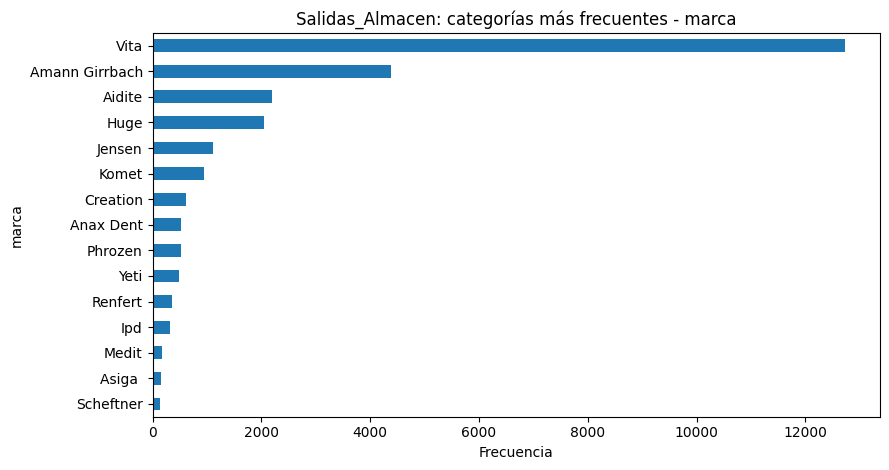


salidas | faltantes: 0 de 27,474
count    27474.000000
mean         9.947296
std         19.555593
min          1.000000
25%          1.000000
50%          3.000000
75%         10.000000
max        353.000000


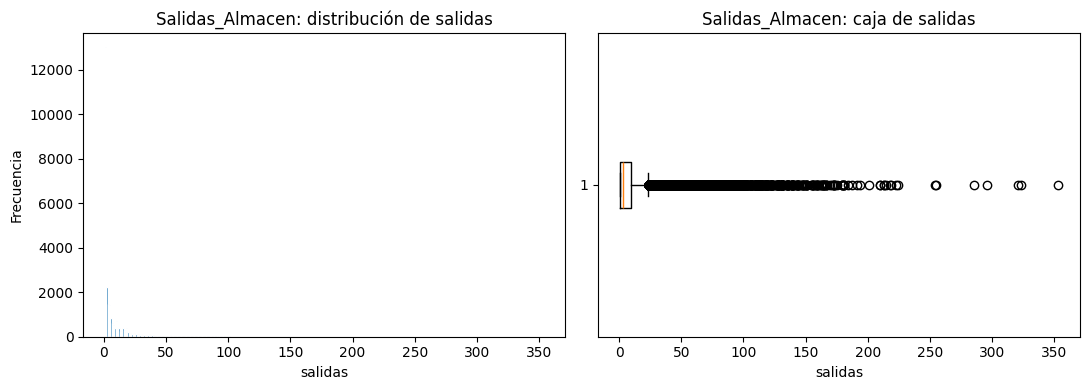


Análisis univariado: Negocios_CRM

nombre_negocio | faltantes: 0 de 5,268
nombre_negocio
Ricardo Casas Zamudio | Vita Mft | Puebla                   17
Laboratorio  - Discos De Fresado - Ciudad De México         11
Delta Sierra Zulu/Fresas Cad Cam/Edo Mex                    10
Eduardo Ivan Vera Velez/Discos Aidite/Edo Mex                9
Paulina Virginia Briseño Martinez/Dientes Vita/Edo Mex       9
Enrique Rodriguez Crespo/Fresas Cad Cam/Cdmx                 8
Pk Digital Lab/Fresas Cad Cam/Edo Mex                        8
Fusion Taller Dental/Dientes Vita/Morelos                    8
Porcelab Servicios Protésicos | Aizir Aidite | Querétaro     8
Victor Hugo Sanchez Bernal/Cameo Press/Edo Mex               7
Ana Elena Ramirez Leija/Cameo Press/Edo Mex                  7
Esther Cruz Vazquez/Dientes Vita/Edo Mex                     7
Operadora  - Dientes Protésicos - Ciudad De México           7
Nubia Adame|Mft|Cdmx                                         7
Miguel Suarez Barea/Disco Am

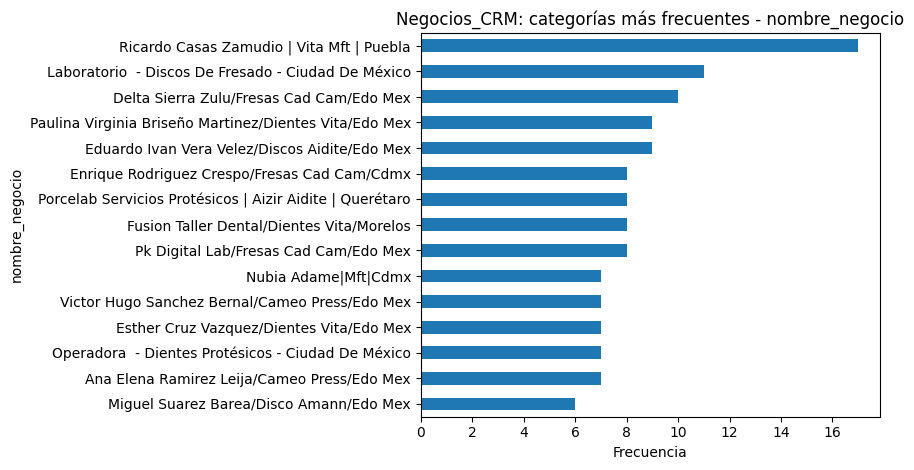


estado | faltantes: 149 de 5,268
estado
Ciudad De México    960
Estado De México    750
Puebla              612
Tamaulipas          272
Nuevo León          212
Coahuila            203
Jalisco             200
Veracruz            188
Querétaro           177
Guanajuato          169
San Luis Potosí     150
Sin dato            149
Michoacán           123
Aguascalientes      115
Yucatán             106


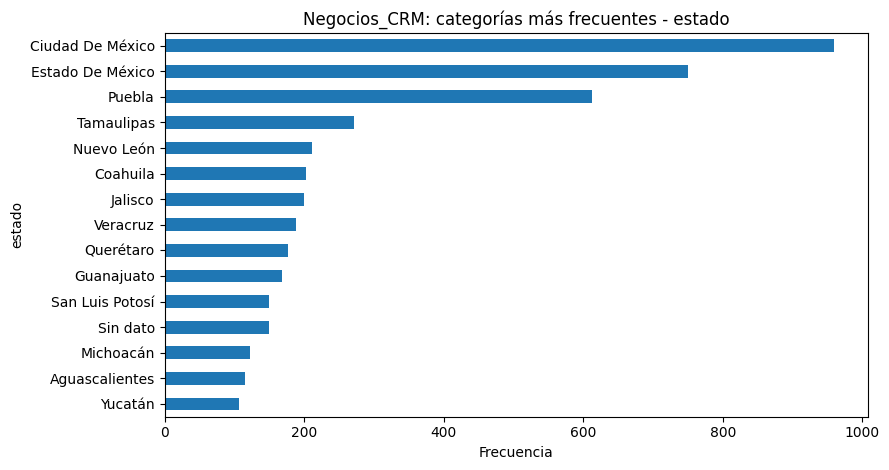


tipo_negocio | faltantes: 560 de 5,268
tipo_negocio
Cliente existente    3817
Cliente nuevo         888
Sin dato              560
Tamaulipas              2
Veracruz                1


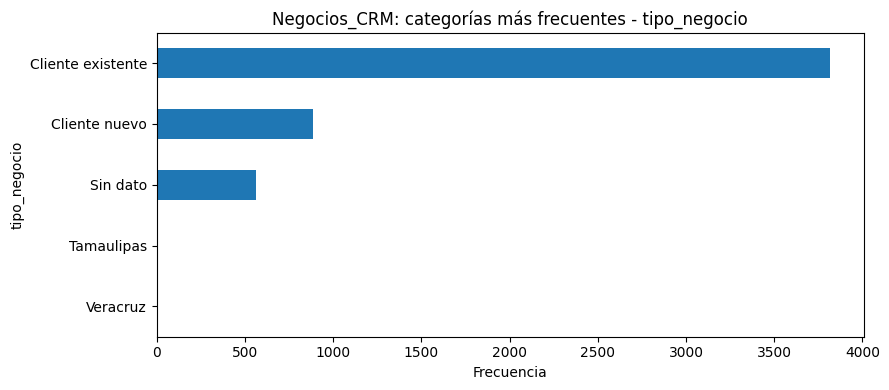


nombre_etapa | faltantes: 22 de 5,268
nombre_etapa
Cierre Ganado                     3763
Cierre Perdido                     691
Ganado                             336
Perdido                            243
Negociación                         42
Lead                                38
Cotización                          32
Calificado Para Comprar             26
Contactado                          25
Sin dato                            22
Envío De Cotización                 12
Necesidad Descubierta               11
Rgistro                              9
Recepción De Pago / Financiera       6
Informacion Enviada                  6


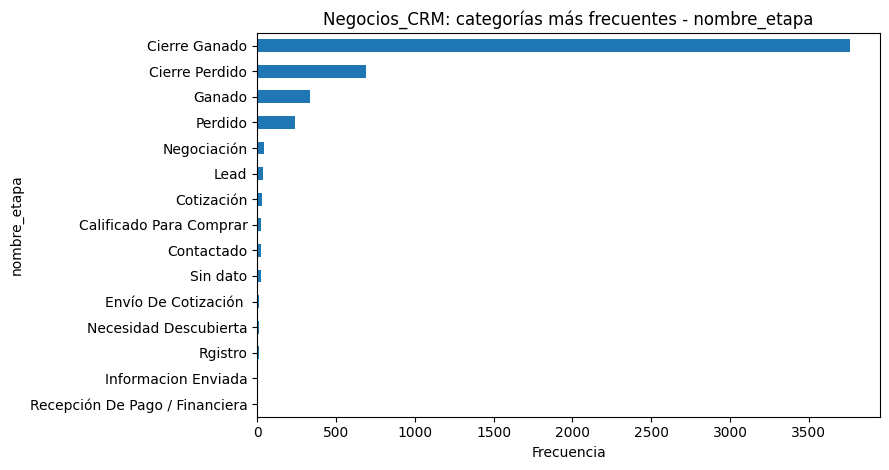


estatus | faltantes: 0 de 5,268
estatus
Cerrado                    5035
Abierto                     210
Calificado Para Comprar      17
Cierre Perdido                4
Perdido                       1
Envío De Cotización           1


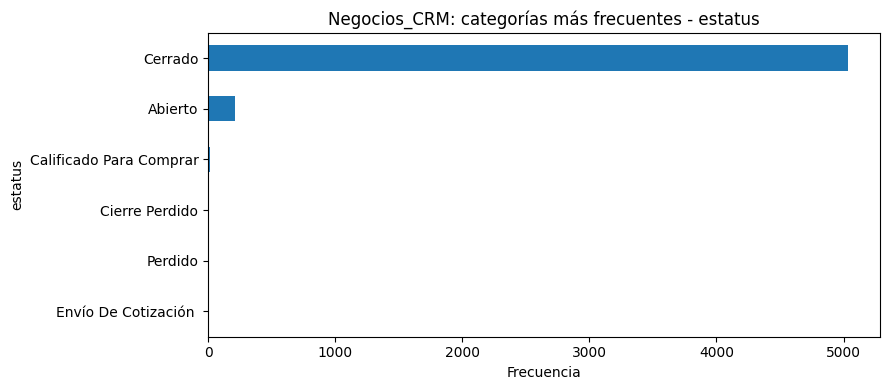


fecha_creacion | faltantes: 30 de 5,268
Rango: 2025-08-05 a 2026-09-04


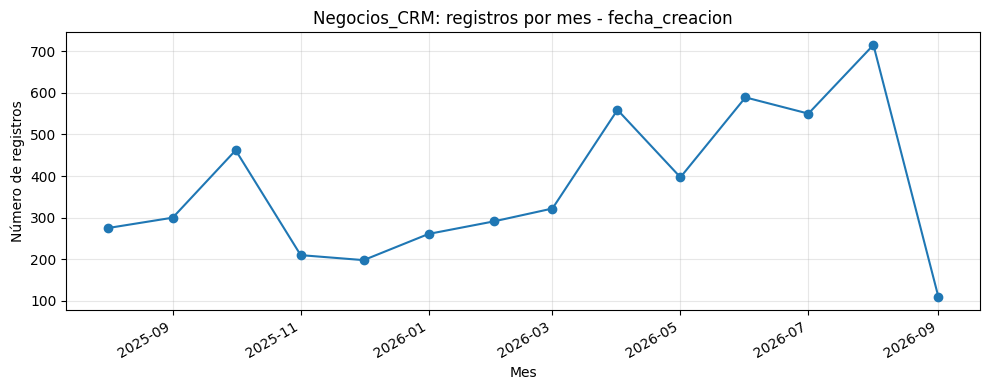


fecha_cierre | faltantes: 109 de 5,268
Rango: 2015-10-26 a 2027-02-03


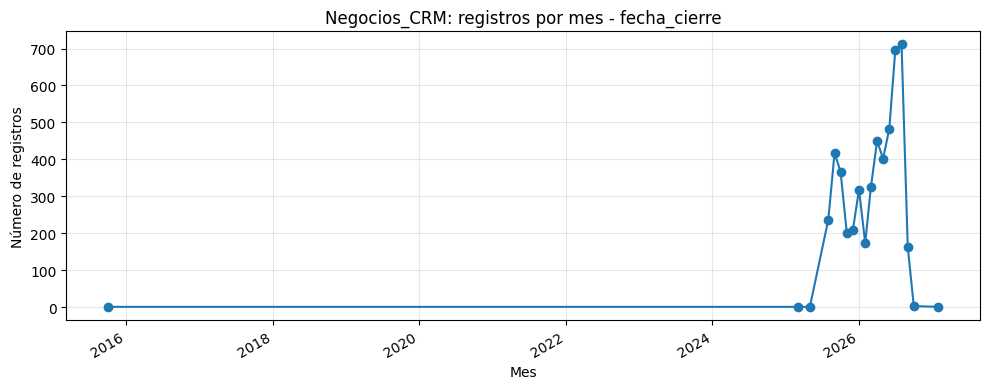


numero_actividades | faltantes: 23 de 5,268
count    5245.000000
mean        0.746997
std         2.869168
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max       123.000000


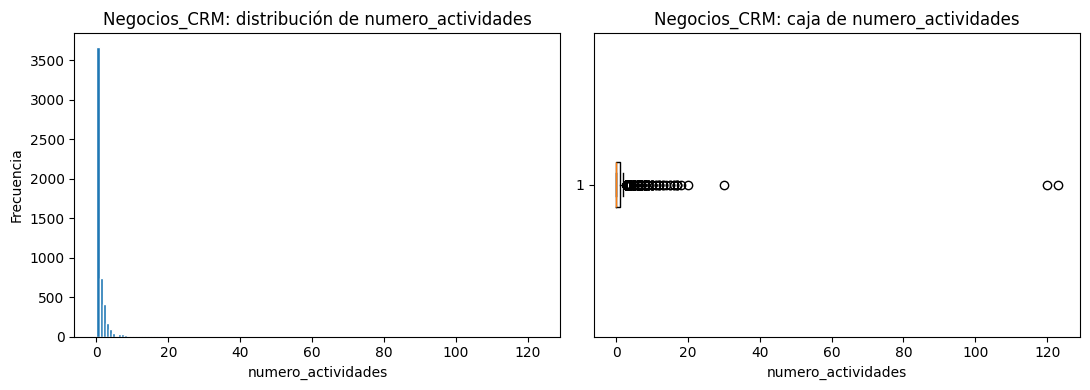


vendedor | faltantes: 406 de 5,268
vendedor
Diego Rodríguez                       1095
Gerardo García                        1007
René Sánchez                           407
Sin dato                               406
Juan Cadena                            405
Esmeralda Monserrat Carreto Deheza     258
Ángel Salas                            240
Luis Manuel Macip Bonilla              188
Erick Juárez                           160
Pietro Pérez                           138
Sergio Ortega Niño                     109
Fernanda Pacheco                       107
José Luis Guillén Hernández            106
Luis Arenas Luna                        86
Luis Ruiz                               76


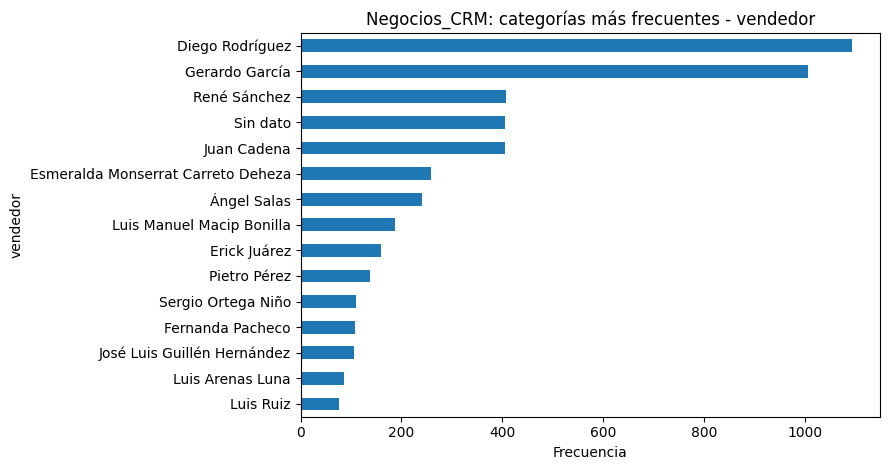


nombre_pipeline | faltantes: 0 de 5,268
nombre_pipeline
Pipeline De Ventas    4385
Ventas - Main          719
Mapeo En Ruta          117
Educación Contínua      24
0                       22
344.82                   1


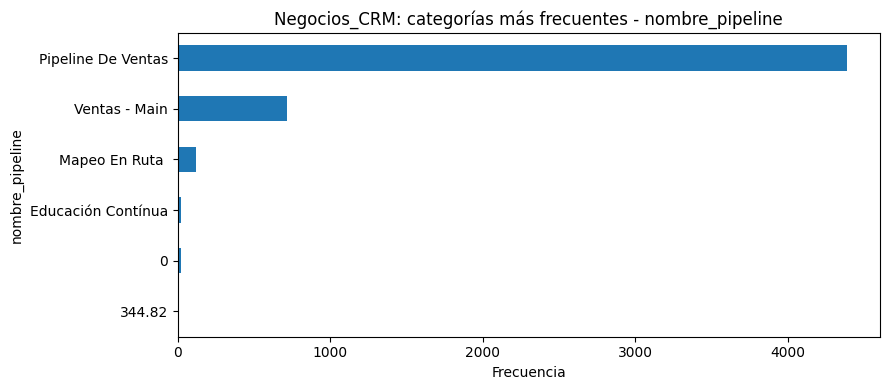


motivo_cierre_perdido | faltantes: 4,381 de 5,268
motivo_cierre_perdido
Sin dato                                4381
No tiene el dinero                       301
Falta de producto                        267
Sin Respuesta                            152
Sin interés detectado                     71
Eligio un producto de la competencia      47
No pasó su crédito (Financiera)           14
No paso su credito                        12
2026-09-01T00:00:00Z                       7
2026-09-02T00:00:00Z                       5
2026-07-29T00:00:00Z                       3
2026-09-03T00:00:00Z                       2
2026-06-15T00:00:00Z                       2
2026-08-25T00:00:00Z                       1
2026-08-10T00:00:00Z                       1


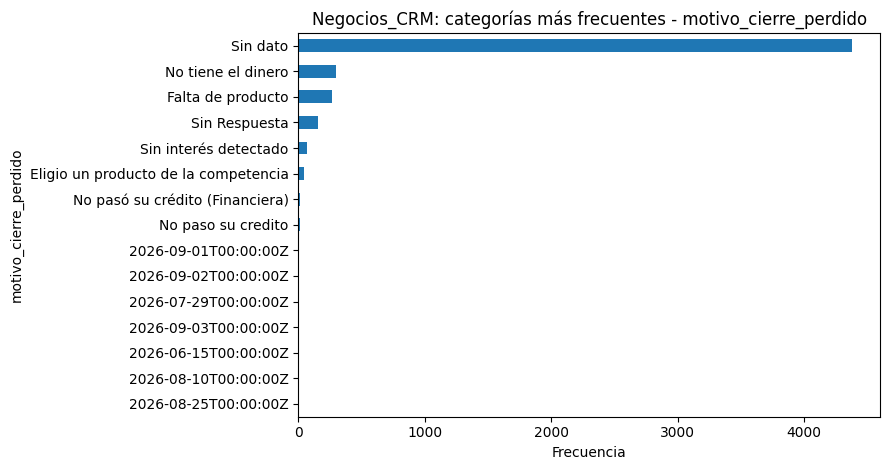


nombre_zona | faltantes: 1,142 de 5,268
nombre_zona
Zona Metropolitana               1555
Zona Sur Este Golfo de México    1261
Sin dato                         1142
Zona Bajío                        720
Zona Occidente Pacífico           434
Zona Noreste                      155
Sin interés detectado               1


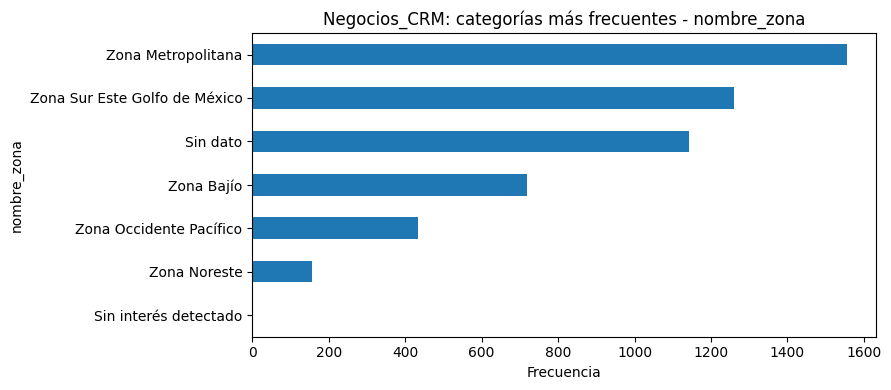

In [9]:
analisis_univariado(
    df_salidas,
    columnas_numericas={"salidas"},
    columnas_fecha={"fecha"},
    nombre_hoja="Salidas_Almacen",
)

analisis_univariado(
    df_negocios,
    columnas_numericas={"numero_actividades"},
    columnas_fecha={"fecha_creacion", "fecha_cierre"},
    nombre_hoja="Negocios_CRM",
)

In [4]:
archivo = pd.ExcelFile("Datos_CLV_2026_Tec_v2.xlsx")
for hoja in archivo.sheet_names:
    muestra = pd.read_excel(archivo, sheet_name=hoja, nrows=0)
    print(f"{hoja}: {list(muestra.columns)}")

Diccionario_Datos: []
Ventas_CLV_2022_2026: ['fecha_documento', 'folio_abreviado', 'folio', 'articulo_id', 'clave_articulo', 'nombre_articulo', 'marca', 'precio_unitario', 'total_unidades', 'total_neto', 'nombre_cliente', 'estado', 'ciudad', 'cp', 'vendedor']
Existencias_04_09_2026: ['articulo_id', 'nombre_articulo', 'marca', 'nombre_almacen', 'existencias', 'valor_total_inventario']
Histórico_Compras: ['folio', 'fecha', 'articulo_id', 'clave_articulo', 'nombre_articulo', 'unidades', 'precio_unitario', 'precio_total_neto']
Clasificación_Articulos: ['articulo_id', 'nombre_articulo', 'categoria']
Salidas_Almacen: ['fecha', 'anio', 'mes', 'articulo_id', 'clave_articulo', 'nombre_articulo', 'marca', 'salidas', 'nombre_almacen']
Ventas_Negadas_CRM: ['id_negocio', 'nombre_etapa', 'estado', 'estatus', 'fecha_creacion', 'fecha_cierre', 'motivo_cierre_perdido']
Negocios_CRM: ['id_negocio', 'nombre_negocio', 'estado', 'tipo_negocio', 'nombre_etapa', 'estatus', 'fecha_creacion', 'fecha_creacion_i